# Jour 4 — Clustering et anomalies

## Corrigé détaillé : comprendre chaque étape

**Idée directrice :** en apprentissage non supervisé, les groupes et les anomalies dépendent des variables, de leur représentation et des hypothèses de l'algorithme.

### Ce que nous cherchons à apprendre
1. Expliquer pourquoi un changement d'unité modifie les distances.
2. Lire une PCA et quantifier ce qu'une projection conserve.
3. Choisir un nombre de groupes avec plusieurs arguments.
4. Comparer K-means, GMM et DBSCAN sur des géométries différentes.
5. Distinguer un score d'anomalie, un seuil et une alerte.
6. Formuler une conclusion argumentée sans vérité terrain complète.

### Comment travailler avec ce corrigé
Pour chaque section, lire la question, anticiper le résultat, exécuter le code, puis comparer son interprétation à la lecture proposée. Expliquer ensuite le résultat avec ses propres mots.

Les jeux `X1` à `X6` sont **six expériences indépendantes sur des données synthétiques**. La PCA de la section 2 ne sert donc pas d'entrée aux algorithmes des sections suivantes. Les étiquettes `y1` et `y4` connues grâce à la simulation servent uniquement à illustrer la structure de référence ; elles ne sont pas fournies aux modèles.

Les résultats chiffrés commentés correspondent aux paramètres ci-dessous, à la graine `42` et à une exécution avec scikit-learn `1.9.1`. Si vous modifiez les données ou les paramètres, refaites les calculs et actualisez votre conclusion.

### Où trouver les réponses aux questions du notebook étudiant ?
Les réponses rédigées sont repérées ci-dessous : les sept questions principales, les cinq questions de la grille d'évaluation et les quatre points de la restitution finale. Chaque réponse précise le constat, sa justification et les limites de la conclusion.

| Repère | Question ou point demandé | Réponse |
|---|---|---|
| Q1 | Changer l'échelle conserve-t-il les proximités ? | [Représentation et distance](#reponse-q1) |
| Q2 | Que conserve une PCA à deux axes ? | [Variance conservée et information perdue](#reponse-q2) |
| Q3 | Comment K-means forme-t-il ses groupes et comment choisir K ? | [Mécanisme et choix argumenté de K](#reponse-q3) |
| Q4 | Pourquoi K-means échoue-t-il sur les lunes ? | [Limite géométrique](#reponse-q4) |
| Q5 | Que gagne-t-on à comparer plusieurs méthodes ? | [Comparaison des hypothèses](#reponse-q5) |
| Q6 | Les détecteurs signalent-ils les mêmes points ? | [Accord et désaccords entre détecteurs](#reponse-q6) |
| Q7 | Comment conclure sans vérité terrain complète ? | [Conclusion argumentée sur ce cas](#reponse-q7) |
| Q7.1 | Les groupes sont-ils stables ? | [Mesures de stabilité](#reponse-q7-1) |
| Q7.2 | Les groupes sont-ils séparés ? | [Réponse par jeu de données](#reponse-q7-2) |
| Q7.3 | Existe-t-il du bruit interprétable ? | [Inspection des points de bruit](#reponse-q7-3) |
| Q7.4 | Les anomalies sont-elles actionnables ? | [Cas à examiner et portée métier](#reponse-q7-4) |
| Q7.5 | Le résultat dépend-il trop des paramètres ? | [Sensibilité mesurée](#reponse-q7-5) |
| Q8.1 | Quelle méthode pour des groupes compacts ? | [Choix et justification](#reponse-q8-1) |
| Q8.2 | Quelle méthode pour des formes courbes ? | [Choix et justification](#reponse-q8-2) |
| Q8.3 | Quel détecteur d'anomalies tester en premier ? | [Choix et justification](#reponse-q8-3) |
| Q8.4 | Que vérifier avant une conclusion métier ? | [Vérifications attendues](#reponse-q8-4) |

La section 8 se termine par une [restitution complète en dix lignes](#synthese-redigee). L'expérience proposée sur `eps` est exécutée et corrigée en Q7.5.

## 0. Préparer l'environnement et lire le code

### À quoi servent les bibliothèques ?
| Outil | Rôle dans ce notebook |
|---|---|
| NumPy (`np`) | Construire les tableaux numériques, sélectionner des colonnes et calculer des sommes. |
| pandas (`pd`) | Présenter les résultats sous forme de tableaux lisibles. |
| Matplotlib (`plt`) | Dessiner les nuages de points et les courbes. |
| Seaborn (`sns`) | Régler le style visuel et la taille des textes des figures. |
| scikit-learn | Générer les données, les transformer, ajuster les modèles et calculer les métriques. |

`sns.set_theme(...)` change la présentation, pas les résultats numériques. `np.random.seed(42)` fixe le générateur aléatoire global de NumPy. Les paramètres `random_state=42` fixent séparément l'aléatoire des générateurs ou modèles concernés. Cela facilite la reproduction d'une expérience dans le même environnement ; cela ne prouve pas que le résultat est stable avec d'autres graines.

### Les conventions à connaître
- `X` est une matrice : une ligne par observation, une colonne par variable. Une forme `(300, 2)` signifie 300 observations décrites par deux variables.
- `labels` contient les numéros de groupes produits par un algorithme. Ces numéros sont des identifiants, pas un classement ni une vérité terrain.
- `fit(X)` apprend des paramètres à partir de `X`.
- `transform(X)` applique une transformation déjà apprise ; `fit_transform(X)` combine apprentissage et transformation.
- `predict(X)` utilise un modèle ajusté pour attribuer des résultats aux observations.
- `fit_predict(X)` ajuste le modèle et renvoie les affectations des observations utilisées.
- Un attribut comme `inertia_` ou `cluster_centers_`, terminé par `_`, contient un résultat appris lors de l'ajustement.

Exécutez les cellules de haut en bas. Dans Jupyter, un tableau placé en dernière ligne d'une cellule s'affiche automatiquement. Pour les figures, `scatter` dessine les points, `c` détermine leur couleur, `cmap` choisit la palette et `s` règle leur taille. `tight_layout()` ajuste les espacements et `show()` affiche la figure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

sns.set_theme(style="whitegrid", context="talk")
np.random.seed(42)

## 1. Représentation et distance

### Question
Si l'on change l'échelle d'une variable, est-ce que la notion de proximité reste la même ?

### Étape 1.1 — Construire une expérience contrôlée
`make_blobs` crée des nuages de points autour de centres :
- `n_samples=300` fixe le nombre total de points ;
- `centers=[...]` donne les coordonnées des trois centres ;
- `cluster_std=[1.0, 1.2, 0.8]` règle la dispersion de chaque nuage : une valeur plus grande produit un nuage plus étalé ;
- `random_state=42` permet de retrouver le même tirage.

`X1` contient les coordonnées et `y1` le groupe d'origine de chaque point. La copie `X1.copy()` permet de modifier les données sans écraser le tableau initial. Dans `X1_scaled_axis[:, 1]`, `:` sélectionne toutes les lignes et `1` la deuxième colonne, car les indices commencent à zéro. Nous multiplions cette colonne par 25.

### Pourquoi cela compte-t-il ?
En deux dimensions, la distance euclidienne au carré vaut :

`d²(A, B) = (a1 - b1)² + (a2 - b2)²`

Après multiplication de la deuxième variable par 25, son terme est multiplié par **625**. Deux points peuvent donc devenir très éloignés selon cette distance simplement à cause du changement d'unité. C'est le même problème lorsqu'on mélange, par exemple, un âge en années et un revenu en euros.

**Attention à la lecture visuelle :** les deux graphiques peuvent sembler identiques, car Matplotlib adapte automatiquement les graduations. Regardez les valeurs de l'axe vertical : les distances numériques ont bien changé.

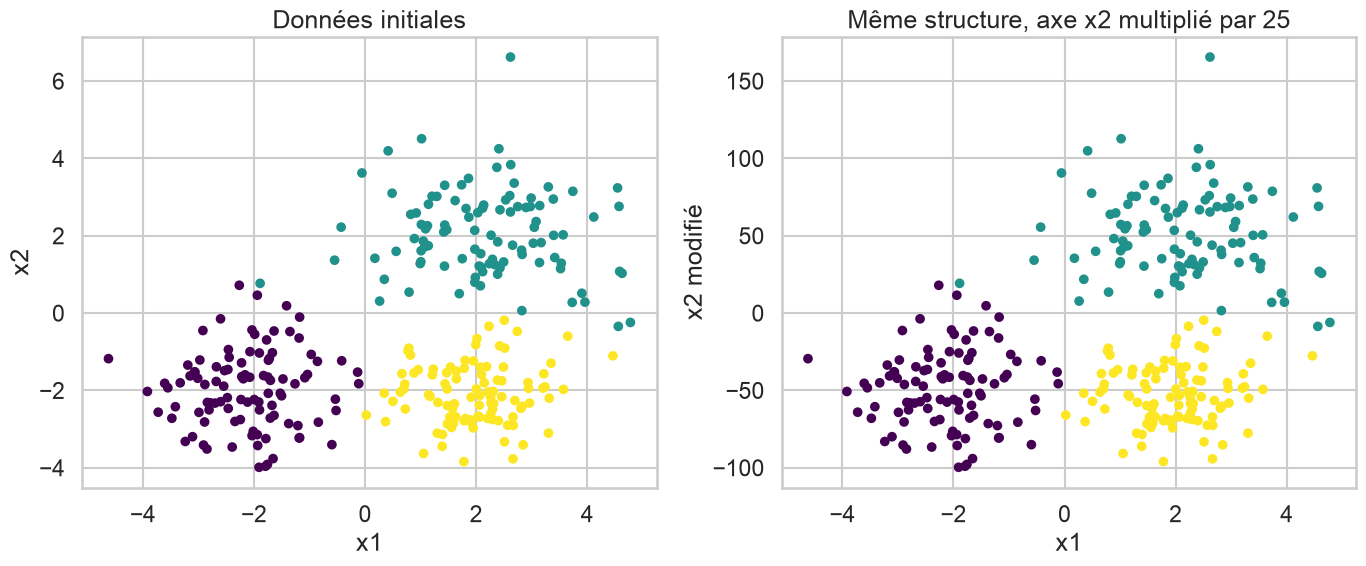

In [2]:
X1, y1 = make_blobs(
    n_samples=300,
    centers=[(-2, -2), (2, 2), (2, -2)],
    cluster_std=[1.0, 1.2, 0.8],
    random_state=42
)

X1_scaled_axis = X1.copy()
X1_scaled_axis[:, 1] *= 25

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X1[:, 0], X1[:, 1], c=y1, cmap='viridis', s=30)
axes[0].set_title('Données initiales')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')

axes[1].scatter(X1_scaled_axis[:, 0], X1_scaled_axis[:, 1], c=y1, cmap='viridis', s=30)
axes[1].set_title('Même structure, axe x2 multiplié par 25')
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2 modifié')

plt.tight_layout()
plt.show()

### Étape 1.2 — Comparer K-means avant et après standardisation
Nous demandons à K-means de former trois groupes avec `n_clusters=3`. Il rapproche chaque observation d'un centre appelé **centroïde**. Son fonctionnement sera détaillé en section 3.

1. `km_raw.fit_predict(X1_scaled_axis)` calcule les groupes sur les valeurs étirées.
2. `StandardScaler().fit_transform(...)` apprend la moyenne et l'écart-type de chaque colonne, puis applique : `z = (x - moyenne) / écart-type`.
3. `km_std.fit_predict(X1_std)` calcule les groupes dans ce nouvel espace.
4. Les deux figures affichent les **mêmes coordonnées étirées**, mais les couleurs viennent de deux ajustements différents. On peut ainsi comparer directement les affectations.

Pour une variable non constante, la standardisation produit une moyenne proche de zéro et un écart-type proche de un. Elle réduit la domination liée aux unités, mais ne rend pas les variables indépendantes, ne les rend pas gaussiennes et ne les borne pas entre 0 et 1.

Donner une variance comparable aux variables reste un **choix de représentation** : cela ne signifie pas que toutes ont la même importance métier.

Référence : [StandardScaler — documentation officielle](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

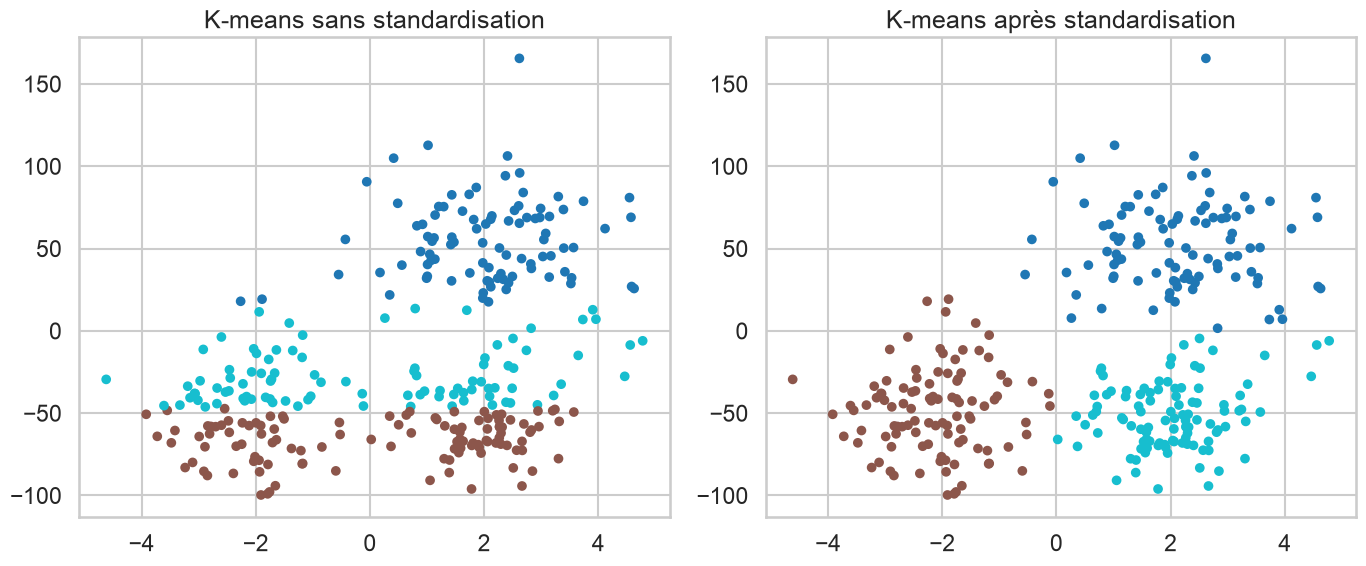

In [3]:
km_raw = KMeans(n_clusters=3, n_init=20, random_state=42)
labels_raw = km_raw.fit_predict(X1_scaled_axis)

scaler = StandardScaler()
X1_std = scaler.fit_transform(X1_scaled_axis)
km_std = KMeans(n_clusters=3, n_init=20, random_state=42)
labels_std = km_std.fit_predict(X1_std)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X1_scaled_axis[:, 0], X1_scaled_axis[:, 1], c=labels_raw, cmap='tab10', s=30)
axes[0].set_title('K-means sans standardisation')

axes[1].scatter(X1_scaled_axis[:, 0], X1_scaled_axis[:, 1], c=labels_std, cmap='tab10', s=30)
axes[1].set_title('K-means après standardisation')

plt.tight_layout()
plt.show()

<a id="reponse-q1"></a>
### Réponse Q1 — Représentation et distance
> Si l'on change l'échelle d'une variable, est-ce que la notion de proximité reste la même ?

**Réponse directe : non, pas en général.** Changer l'échelle d'une seule variable modifie son poids dans la distance euclidienne et peut changer l'ordre des voisins. Dans notre expérience, multiplier `x2` par 25 multiplie sa contribution à la distance au carré par 625.

**Lecture du résultat :** sans standardisation, K-means découpe principalement le nuage selon la hauteur : la deuxième variable domine son critère. Des observations éloignées horizontalement peuvent recevoir la même étiquette. Après standardisation, la séparation gauche/droite contribue davantage et les trois nuages d'origine sont mieux retrouvés visuellement.

**Exemple chiffré :** depuis A = (0, 0), C = (0, 1) est plus proche que B = (3, 0), car 1 < 3. Après multiplication de la deuxième coordonnée par 25, les distances deviennent 25 vers C et 3 vers B : le plus proche voisin a changé. Si tous les axes sont multipliés par le même facteur positif, en revanche, l'ordre des distances est conservé.

**Conclusion métier :** avant de segmenter des observations, il faut justifier les variables, leurs unités et leur pondération. Un résultat de clustering dépend de cette préparation.

**Pour vérifier votre compréhension :** pourquoi changer seulement la couleur ou la taille des points ne changerait-il pas les groupes ? Parce que ces réglages concernent l'affichage, tandis que la standardisation transforme les nombres fournis à l'algorithme.

## 2. PCA : projeter sans prétendre tout conserver

### Question
Que garde exactement une PCA lorsqu'on passe de plusieurs dimensions à deux axes ?

La PCA, ou **analyse en composantes principales (ACP)**, construit de nouveaux axes, combinaisons linéaires des variables. Le premier explique la plus grande variance possible ; les suivants expliquent le plus de variance restante tout en étant orthogonaux aux précédents. Elle ne cherche pas des classes ni des groupes.

### Étape 2.1 — Construire quatre variables à partir de trois facteurs
- `rng = np.random.RandomState(42)` crée un générateur aléatoire local.
- `base` contient 500 observations de trois facteurs gaussiens.
- Chaque expression combine ces facteurs avec des coefficients différents.
- `np.column_stack` assemble les quatre colonnes obtenues dans `X2`, de forme `(500, 4)`.

Les variables partagent des facteurs : certaines portent donc de l'information redondante. Comme nous les construisons à partir de seulement trois facteurs, elles ne peuvent pas apporter quatre directions indépendantes de variation.

### Étape 2.2 — Ajuster la PCA complète
Nous standardisons les colonnes pour travailler sur des échelles comparables. La PCA de scikit-learn centre les données, mais **ne les standardise pas automatiquement**.

`PCA().fit(X2_std)` apprend ici les quatre axes disponibles. `explained_variance_ratio_` donne la fraction de variance expliquée par chaque axe, et `np.cumsum` additionne progressivement ces fractions. Le tableau permet de distinguer l'apport d'un axe de l'apport cumulé de plusieurs axes.

Référence : [PCA — documentation officielle](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).

In [4]:
rng = np.random.RandomState(42)
base = rng.normal(size=(500, 3))
X2 = np.column_stack([
    2.5 * base[:, 0] + 0.3 * base[:, 1],
    2.0 * base[:, 0] - 0.4 * base[:, 1] + 0.2 * base[:, 2],
    0.5 * base[:, 0] + 1.7 * base[:, 1],
    0.2 * base[:, 0] + 0.1 * base[:, 1] + 2.2 * base[:, 2],
])

X2_std = StandardScaler().fit_transform(X2)
pca_full = PCA().fit(X2_std)
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

pd.DataFrame({
    'composante': np.arange(1, len(var_exp) + 1),
    'variance_expliquee': var_exp,
    'variance_cumulee': var_cum
})

,composante,variance_expliquee,variance_cumulee
0,1,0.514571,0.514571
1,2,0.249089,0.763660
2,3,0.236340,1.000000
3,4,0.000000,1.000000


### Étape 2.3 — Lire la variance expliquée
Dans le graphique suivant, les barres montrent l'apport individuel des composantes et la courbe rouge leur apport cumulé. Les axes sont numérotés de 1 à 4 pour la lecture, même si les tableaux Python commencent à l'indice 0.

| Composante | Variance expliquée | Variance cumulée |
|---|---:|---:|
| PC1 | 51,46 % | 51,46 % |
| PC2 | 24,91 % | 76,37 % |
| PC3 | 23,63 % | 100,00 % |
| PC4 | Environ 0 % | 100,00 % |

La quatrième composante presque nulle vient de la construction des données à partir de trois facteurs. Ce n'est pas une règle générale disant que la dernière composante d'une PCA serait toujours inutile.

**Correction :** pour conserver au moins 90 % de la variance de ce jeu standardisé, il faut trois composantes. En retenir deux facilite le dessin, mais ce choix a un coût mesurable.

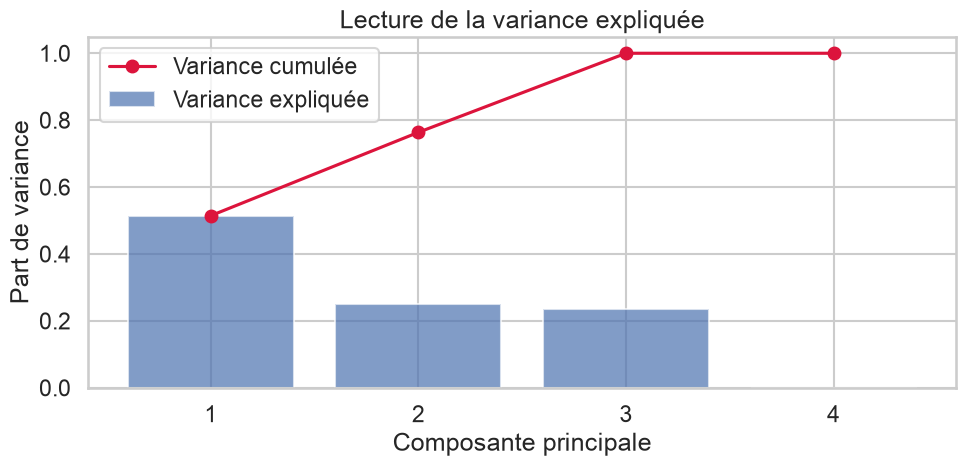

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(var_exp) + 1), var_exp, alpha=0.7, label='Variance expliquée')
ax.plot(range(1, len(var_cum) + 1), var_cum, marker='o', color='crimson', label='Variance cumulée')
ax.set_xlabel('Composante principale')
ax.set_ylabel('Part de variance')
ax.set_title('Lecture de la variance expliquée')
ax.set_xticks(range(1, len(var_exp) + 1))
ax.legend()
plt.tight_layout()
plt.show()

### Étape 2.4 — Projeter les observations en deux dimensions
`PCA(n_components=2)` retient les deux premières directions. `fit_transform` apprend ces directions puis calcule les nouvelles coordonnées des observations. `X2_pca` a donc la forme `(500, 2)`.

Chaque point représente toujours une observation, mais ses coordonnées sont maintenant des valeurs sur PC1 et PC2. Ces axes ne correspondent plus directement aux variables initiales : chacun est une combinaison de celles-ci. `alpha=0.7` rend les points partiellement transparents pour mieux voir les superpositions.

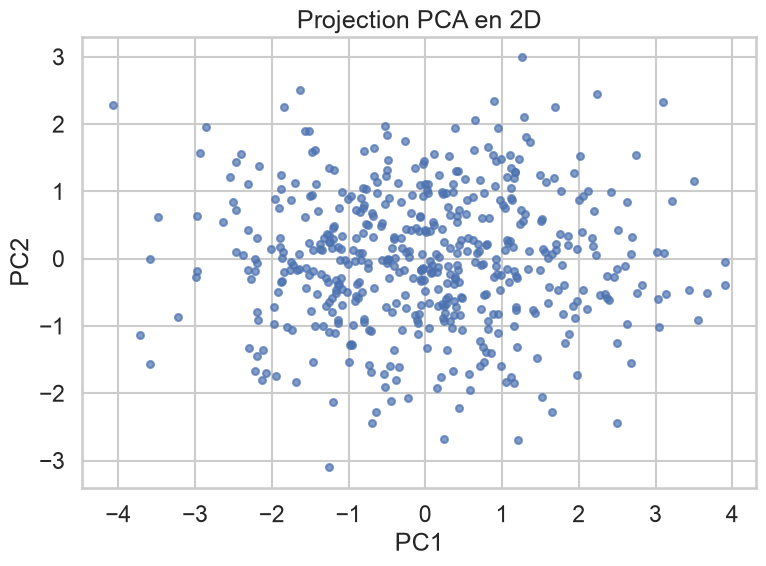

In [6]:
pca_2 = PCA(n_components=2)
X2_pca = pca_2.fit_transform(X2_std)

plt.figure(figsize=(8, 6))
plt.scatter(X2_pca[:, 0], X2_pca[:, 1], s=25, alpha=0.7)
plt.title('Projection PCA en 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

<a id="reponse-q2"></a>
### Réponse Q2 — Ce que conserve la PCA
> Que garde exactement une PCA lorsqu'on passe de plusieurs dimensions à deux axes ?

**Réponse directe :** elle garde les coordonnées de chaque observation sur les deux directions orthogonales qui expliquent ensemble le plus de variance dans l'espace fourni. Les 500 observations restent présentes, mais elles n'ont plus que deux coordonnées au lieu de quatre. Les composantes écartées ne sont plus représentées.

**Lecture du résultat :** la projection conserve **76,37 % de la variance** et laisse de côté environ **23,63 %**. Des observations proches à l'écran peuvent être séparées selon la troisième composante, désormais invisible. Ici, le nuage projeté n'apporte pas de preuve de groupes nettement distincts.

**Ce qu'elle ne garantit pas :** elle ne conserve pas exactement toutes les distances ni nécessairement l'information utile à une décision métier. Une direction peu variable peut être importante pour une tâche. Ici, garder au moins 90 % de la variance demande trois composantes, et non deux.

**Erreur à éviter :** « 76,37 % de variance conservée » ne signifie pas « 76,37 % de bonnes prédictions ». Aucune cible n'est prédite dans cette expérience.

**Conclusion métier :** la carte 2D est utile pour explorer les données, mais il faut quantifier ce qu'elle masque avant de s'appuyer sur elle pour décider.

## 3. K-means : inertie et compromis sur K

### Question
Comment K-means choisit-il ses groupes, et pourquoi le choix de K ne découle-t-il pas automatiquement d'un seul graphique ?

### Étape 3.1 — Comprendre le mécanisme
K-means alterne deux opérations après initialisation de K centroïdes :
1. Affecter chaque point au centroïde le plus proche.
2. Recalculer chaque centroïde comme la moyenne des points qui lui sont affectés.

Il répète ces opérations jusqu'à convergence ou jusqu'à sa limite d'itérations. Il cherche à réduire l'**inertie** : la somme des distances au carré entre les points et leur centroïde affecté.

`n_clusters=k` fixe K. `n_init=20` essaie vingt initialisations et conserve celle donnant la plus petite inertie : ce n'est pas un nombre d'itérations. Plusieurs essais réduisent le risque d'une mauvaise solution locale, sans garantir l'optimum global.

### Étape 3.2 — Tester plusieurs valeurs de K
Nous générons 500 points autour de quatre centres, puis les standardisons. Le `_` dans `X3, _` indique que les étiquettes du générateur ne sont pas utilisées. La boucle `range(2, 8)` teste K = 2, 3, 4, 5, 6 et 7. Pour chaque K, elle enregistre :
- `km.inertia_` : compacité autour des centroïdes ;
- `silhouette_score(...)` : compacité et séparation entre groupes.

Pour un point, la silhouette vaut `(b - a) / max(a, b)`, où `a` est sa distance moyenne aux autres points de son groupe et `b` la plus petite distance moyenne à un autre groupe. Une valeur proche de 1 traduit une bonne séparation, proche de 0 une position frontière, et négative une affectation potentiellement peu cohérente avec cette distance. Le score retourné est la moyenne sur les points.

Références : [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) et [silhouette_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html).

In [7]:
X3, _ = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=[0.7, 0.9, 1.1, 0.6],
    random_state=42
)
X3_std = StandardScaler().fit_transform(X3)

results = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X3_std)
    results.append({
        'K': k,
        'inertie': km.inertia_,
        'silhouette': silhouette_score(X3_std, labels)
    })

res_k = pd.DataFrame(results)
res_k

,K,inertie,silhouette
0,2,518.696780,0.566978
1,3,111.459167,0.759199
2,4,21.247270,0.843560
3,5,17.891268,0.720762
4,6,15.313867,0.597471
5,7,13.521154,0.596586


### Étape 3.3 — Croiser les deux diagnostics
À gauche, nous cherchons un **coude** : le moment où ajouter des groupes réduit beaucoup moins l'inertie. À droite, nous cherchons des valeurs de K avec une silhouette élevée.

| K | Inertie, environ | Silhouette, environ |
|---:|---:|---:|
| 2 | 518,70 | 0,567 |
| 3 | 111,46 | 0,759 |
| 4 | 21,25 | 0,844 |
| 5 | 17,89 | 0,721 |
| 6 | 15,31 | 0,597 |
| 7 | 13,52 | 0,597 |

L'inertie optimale ne peut pas augmenter quand on autorise davantage de centres. En pratique, les solutions locales peuvent perturber cette propriété entre des ajustements séparés. Ici, elle diminue bien à chaque étape. **Choisir simplement l'inertie la plus faible favoriserait trop de groupes.**

La silhouette culmine à K = 4. Elle favorise cependant les groupes compacts et bien séparés : elle n'est pas un arbitre universel entre toutes les géométries.

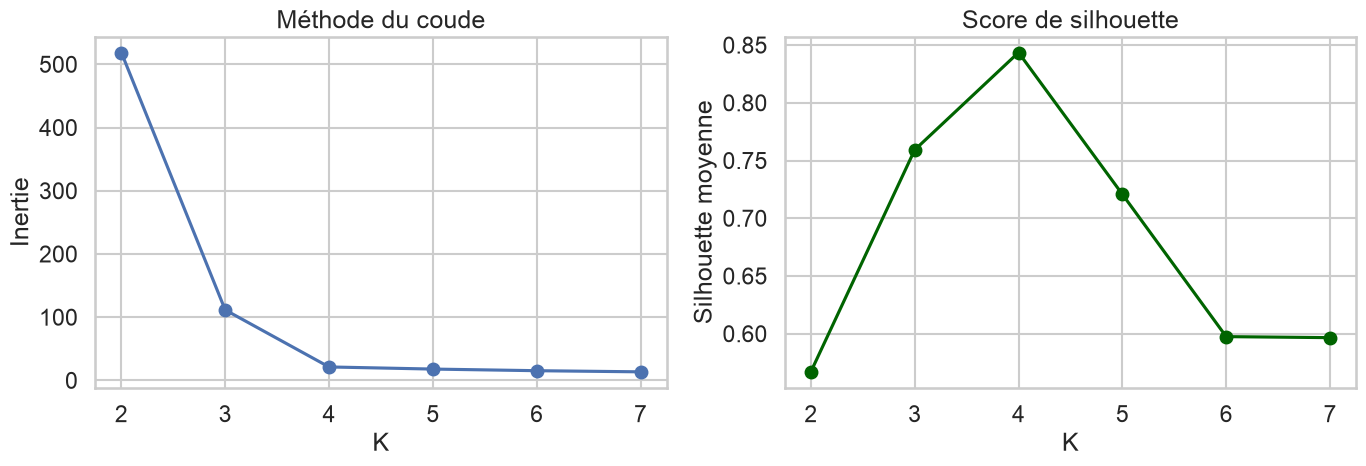

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(res_k['K'], res_k['inertie'], marker='o')
axes[0].set_title('Méthode du coude')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertie')

axes[1].plot(res_k['K'], res_k['silhouette'], marker='o', color='darkgreen')
axes[1].set_title('Score de silhouette')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette moyenne')

plt.tight_layout()
plt.show()

### Étape 3.4 — Ajuster et afficher la solution retenue
`k_best = 4` est un choix explicite à partir des diagnostics précédents, pas une valeur calculée automatiquement par cette ligne. Nous réajustons K-means avec ce K et affichons :
- les observations colorées selon leur groupe ;
- les centroïdes appris, stockés dans `cluster_centers_`, sous forme de croix noires.

Les coordonnées sont standardisées : un centroïde est une moyenne dans cet espace, pas nécessairement une observation réellement présente dans les données.

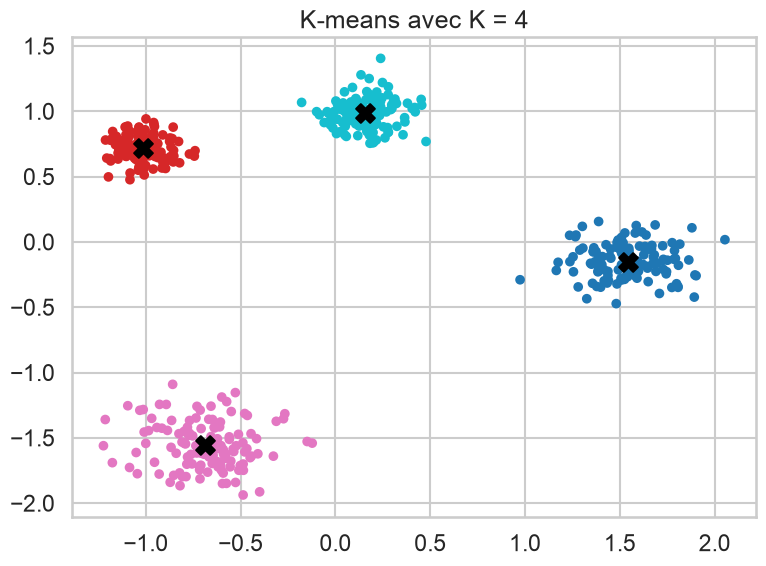

In [9]:
k_best = 4
km4 = KMeans(n_clusters=k_best, n_init=20, random_state=42)
labels4 = km4.fit_predict(X3_std)

plt.figure(figsize=(8, 6))
plt.scatter(X3_std[:, 0], X3_std[:, 1], c=labels4, cmap='tab10', s=30)
plt.scatter(km4.cluster_centers_[:, 0], km4.cluster_centers_[:, 1], c='black', s=180, marker='X')
plt.title(f'K-means avec K = {k_best}')
plt.tight_layout()
plt.show()

<a id="reponse-q3"></a>
### Réponse Q3 — Former les groupes et choisir K
> Comment K-means choisit-il ses groupes, et pourquoi le choix de K ne découle-t-il pas automatiquement d'un seul graphique ?

**Comment les groupes sont formés :** pour un K fixé, K-means alterne l'affectation au centroïde le plus proche et le recalcul des centroïdes par moyenne. Il cherche une petite inertie. Avec `n_init=20`, il retient la meilleure de vingt initialisations selon ce critère.

**Pourquoi un graphique ne suffit pas :** l'inertie favorise mécaniquement l'ajout de centres et le coude peut être ambigu. La silhouette favorise certaines géométries et ne mesure ni la stabilité ni l'utilité métier. Il faut donc croiser les diagnostics.

**Choix pour ce cas :** K = 4 est bien soutenu dans cette expérience : le coude est marqué, la silhouette atteint environ **0,844** et les groupes sont visuellement séparés. Passer à K = 5 réduit encore l'inertie, mais dégrade la silhouette en subdivisant la structure.

Nous savons aussi que le générateur a créé quatre centres. Cette information explique le caractère pédagogique de l'exemple ; elle serait inconnue sur un jeu métier non étiqueté.

**Vérification complémentaire :** la réponse Q7.1 mesure la stabilité de cette solution sur trois graines et trois sous-échantillons. Elle complète l'argument en faveur de K = 4, sans établir l'existence de quatre catégories métier.

**Conclusion métier :** quatre segments constituent ici une hypothèse de travail crédible, à confirmer par leurs profils et leur stabilité. Une bonne silhouette ne leur donne pas automatiquement un sens opérationnel.

## 4. Quand K-means échoue : les deux lunes

### Question
Pourquoi une méthode efficace sur des groupes compacts peut-elle échouer sur une structure courbe ?

### Étape 4.1 — Changer de géométrie
`make_moons` crée deux formes courbes imbriquées. Nous générons 400 points. `noise=0.07` est l'écart-type du bruit gaussien ajouté aux coordonnées, **pas un pourcentage de points anormaux**. Nous standardisons ensuite les variables.

K-means reçoit `n_clusters=2`, mais une affectation au centre le plus proche favorise des régions convexes, séparées par des frontières droites dans ce cas. Il ne peut donc pas suivre naturellement les deux arcs.

### Étape 4.2 — Comprendre DBSCAN
DBSCAN recherche des régions denses reliées entre elles :
- `eps=0.25` définit le rayon du voisinage, dans l'espace standardisé ;
- `min_samples=5` demande au moins cinq observations dans ce voisinage, **point lui-même inclus**, pour former un point cœur ;
- des points cœurs reliés par une chaîne de voisinages appartiennent au même groupe ;
- un point non cœur proche d'un cœur peut être rattaché comme point de bord ;
- un point non rattaché reçoit l'étiquette `-1`, qui signifie « bruit ».

Un groupe peut être beaucoup plus large que `eps` : ce rayon décrit une proximité locale, pas le diamètre maximal du groupe. DBSCAN ne demande pas K, mais demande bien des paramètres qui définissent ce que nous appelons « dense ».

### Étape 4.3 — Comparer les trois panneaux
Le premier utilise les étiquettes du générateur `y4` comme référence pédagogique. Le deuxième utilise les affectations de K-means, le troisième celles de DBSCAN. Aucun des deux modèles n'utilise `y4` pour s'ajuster.

Référence : [DBSCAN — documentation officielle](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html).

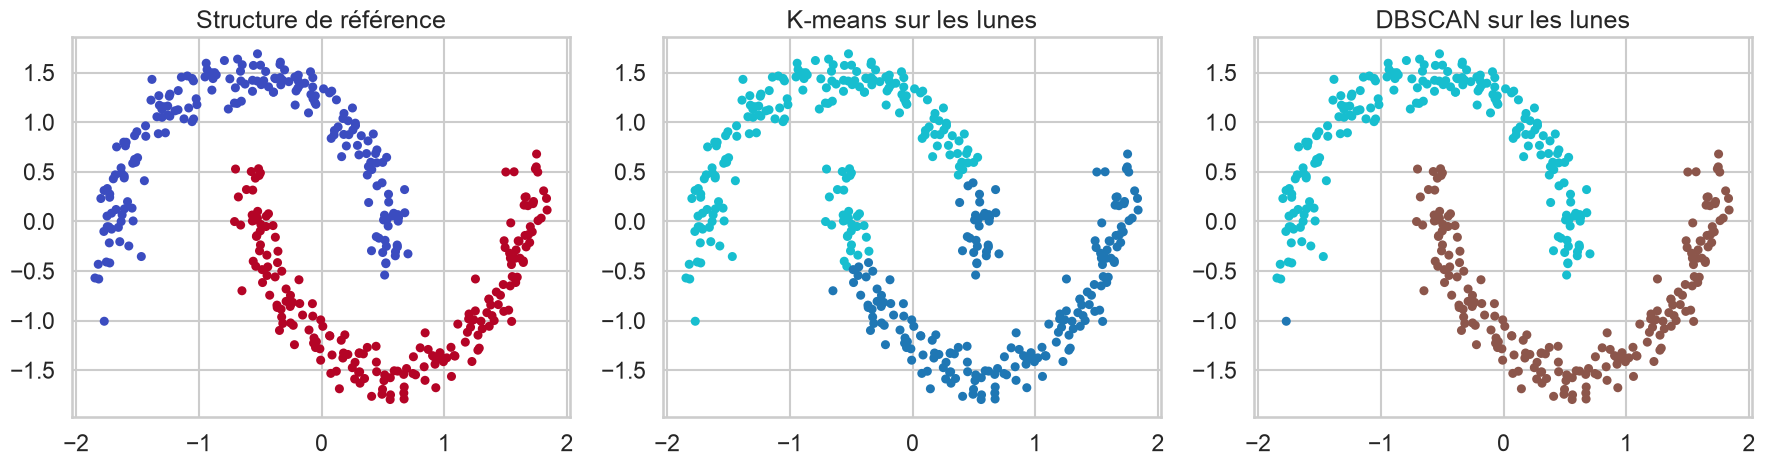

In [10]:
X4, y4 = make_moons(n_samples=400, noise=0.07, random_state=42)
X4_std = StandardScaler().fit_transform(X4)

km_moons = KMeans(n_clusters=2, n_init=20, random_state=42)
labels_km_moons = km_moons.fit_predict(X4_std)

db_moons = DBSCAN(eps=0.25, min_samples=5)
labels_db_moons = db_moons.fit_predict(X4_std)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(X4_std[:, 0], X4_std[:, 1], c=y4, cmap='coolwarm', s=25)
axes[0].set_title('Structure de référence')

axes[1].scatter(X4_std[:, 0], X4_std[:, 1], c=labels_km_moons, cmap='tab10', s=25)
axes[1].set_title('K-means sur les lunes')

axes[2].scatter(X4_std[:, 0], X4_std[:, 1], c=labels_db_moons, cmap='tab10', s=25)
axes[2].set_title('DBSCAN sur les lunes')

plt.tight_layout()
plt.show()

<a id="reponse-q4"></a>
### Réponse Q4 — La limite de K-means sur les lunes
> Pourquoi une méthode efficace sur des groupes compacts peut-elle échouer sur une structure courbe ?

**Réponse directe :** la proximité à un centre ne décrit pas la même structure que la continuité d'une courbe. Avec deux centroïdes, K-means sépare le plan par une frontière droite. Or les deux lunes sont imbriquées : deux points de lunes différentes peuvent être plus proches que deux points éloignés sur une même lune. Une séparation par centres coupe donc les arcs.

**Lecture du résultat :** DBSCAN suit les deux lunes : nous obtenons **200 points dans un groupe, 199 dans l'autre et 1 point de bruit**. On peut vérifier les effectifs avec `np.unique(labels_db_moons, return_counts=True)` ; l'étiquette `-1` correspond au bruit.

Les couleurs n'ont pas de sens fixe entre les panneaux. Un groupe bleu chez un modèle ne correspond pas nécessairement au groupe bleu chez l'autre. De même, la palette ne réserve pas automatiquement le noir aux points de bruit.

**Pourquoi DBSCAN fait mieux ici :** les voisinages denses forment des chaînes le long des arcs. DBSCAN peut les suivre sans représenter chaque lune par un centre unique. Donner le bon K à K-means ne corrige donc pas cette limite géométrique.

**Conclusion métier :** si les comportements forment des structures courbes, une méthode par densité peut être plus adaptée qu'une méthode à centroïdes. Ce résultat ne prouve pas que DBSCAN est supérieur sur tous les jeux de données.

## 5. Comparer plusieurs familles sur le même jeu de données

### Question
Que gagne-t-on à confronter plusieurs hypothèses de structure sur les mêmes points ?

### Étape 5.1 — Préparer une comparaison commune
Nous générons 500 observations autour de trois centres avec des dispersions différentes. `np.vstack` ajoute trois observations éloignées, soit **503 points** au total. Les trois méthodes reçoivent exactement le même tableau standardisé `X5_std`.

| Méthode | Hypothèse utilisée ici | Paramètres principaux |
|---|---|---|
| K-means | Proximité à trois centroïdes | `n_clusters=3`, `n_init=20` |
| GMM | Mélange de trois distributions gaussiennes | `n_components=3` |
| DBSCAN | Régions connectées suffisamment denses | `eps=0.30`, `min_samples=6` |

### Étape 5.2 — Comprendre le GMM
Un **Gaussian Mixture Model**, ou mélange gaussien, apprend pour chaque composante un poids, une moyenne et une covariance. La covariance décrit sa dispersion et son orientation ; avec le réglage par défaut `covariance_type='full'`, les composantes peuvent avoir des formes elliptiques différentes.

Son ajustement alterne une estimation des probabilités d'appartenance aux composantes et une mise à jour de leurs paramètres : c'est l'idée de l'algorithme EM.

Dans `.fit(X5_std).predict(X5_std)`, `fit` apprend le mélange et `predict` choisit la composante la plus probable pour chaque point. L'affichage est donc une affectation **dure**, même si le modèle permet des appartenances probabilistes avec `predict_proba`. Ces probabilités dépendent des hypothèses du mélange ; elles ne prouvent pas l'existence de catégories métier.

### Étape 5.3 — Lire la boucle d'affichage
Le dictionnaire `models` contient ici des **tableaux d'étiquettes**, malgré son nom. `zip(axes, models.items())` associe chaque panneau à un nom de méthode et à ses étiquettes, puis dessine le même nuage avec les couleurs correspondantes.

Référence : [GaussianMixture — documentation officielle](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html).

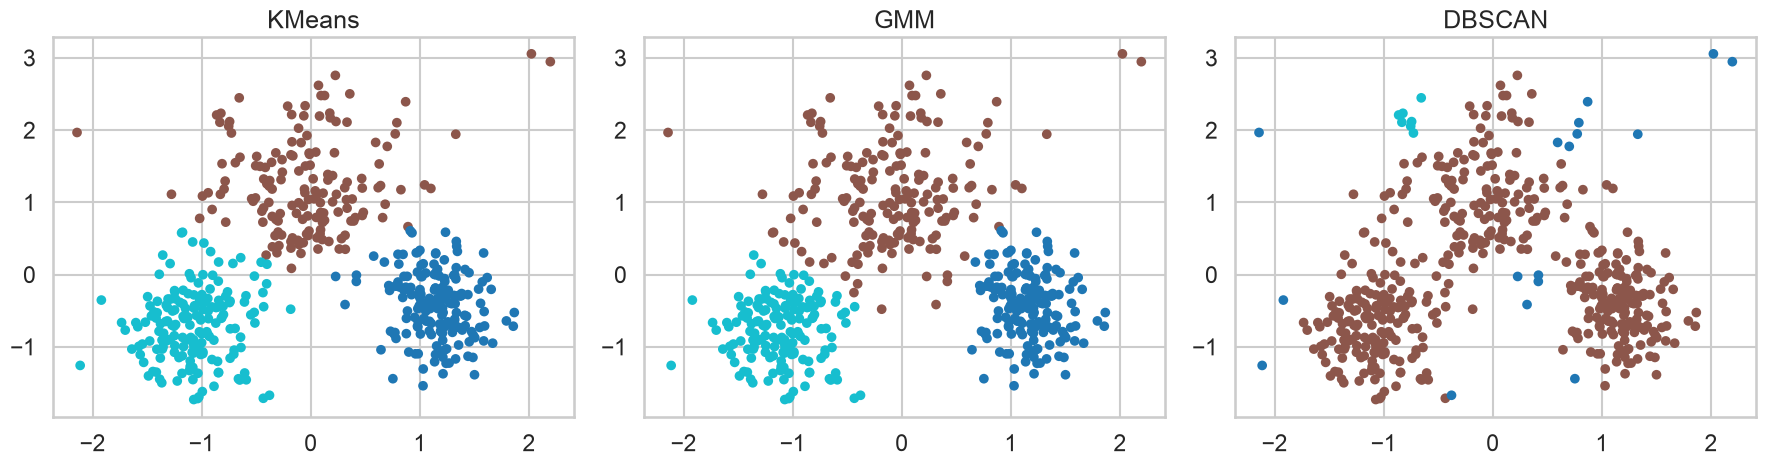

In [11]:
X5, _ = make_blobs(
    n_samples=500,
    centers=[(-3, -1), (0, 2.5), (3.5, -0.5)],
    cluster_std=[0.9, 1.3, 0.8],
    random_state=42
)
X5 = np.vstack([X5, np.array([[6, 6], [6.5, 5.8], [-6, 4]])])
X5_std = StandardScaler().fit_transform(X5)

models = {
    'KMeans': KMeans(n_clusters=3, n_init=20, random_state=42).fit_predict(X5_std),
    'GMM': GaussianMixture(n_components=3, random_state=42).fit(X5_std).predict(X5_std),
    'DBSCAN': DBSCAN(eps=0.30, min_samples=6).fit_predict(X5_std),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, labels) in zip(axes, models.items()):
    ax.scatter(X5_std[:, 0], X5_std[:, 1], c=labels, cmap='tab10', s=30)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### Étape 5.4 — Vérifier les effectifs plutôt que compter les couleurs
La cellule suivante complète la figure par un bilan numérique. Pour chaque méthode :
1. `labels != -1` sélectionne les observations rattachées à un groupe.
2. `np.unique(..., return_counts=True)` renvoie les identifiants présents et leurs effectifs.
3. `len(groupes)` compte les groupes en excluant le bruit.
4. `np.sum(labels == -1)` compte les points de bruit.

K-means et le GMM n'ont pas de classe de bruit dans cette utilisation : ils affectent aussi les trois observations éloignées à une composante ou à un groupe. **Zéro point étiqueté bruit ne signifie donc pas zéro observation atypique.**

In [12]:
bilan_modeles = []
for nom, labels in models.items():
    groupes, effectifs = np.unique(labels[labels != -1], return_counts=True)
    bilan_modeles.append({
        'methode': nom,
        'nombre_groupes': len(groupes),
        'effectifs_groupes': effectifs.tolist(),
        'points_bruit': int(np.sum(labels == -1)),
    })

pd.DataFrame(bilan_modeles)

,methode,nombre_groupes,effectifs_groupes,points_bruit
0,KMeans,3,"[171, 156, 176]",0
1,GMM,3,"[166, 175, 162]",0
2,DBSCAN,2,"[479, 7]",17


<a id="reponse-q5"></a>
### Réponse Q5 — Intérêt de comparer les familles
> Que gagne-t-on à confronter plusieurs hypothèses de structure sur les mêmes points ?

**Réponse directe :** on peut distinguer les structures retrouvées par plusieurs méthodes des découpages propres à une hypothèse. Les données et leur standardisation étant identiques, les désaccords révèlent ici le rôle du critère choisi : distance à des centres, mélange de densités gaussiennes ou connexion par densité.

**Lecture du résultat :** K-means et le GMM donnent chacun trois groupes, comme demandé. Leurs frontières diffèrent, notamment dans les zones de recouvrement. Un GMM peut affecter un point éloigné à une composante : une probabilité relative d'appartenance élevée ne garantit pas que le point soit fréquent sous le modèle.

Avec les paramètres retenus, DBSCAN produit **deux groupes de 479 et 7 points, ainsi que 17 points de bruit**. Il ne retrouve donc pas les trois nuages attendus visuellement : des connexions denses relient une grande partie des observations en un seul groupe.

Ce résultat illustre une limite importante : un rayon global peut fusionner des régions reliées et traiter différemment des nuages de densités différentes. Réduire `eps` impose une densité plus forte et peut fragmenter les groupes ou augmenter le bruit ; l'augmenter peut fusionner encore davantage les groupes.

**Gain concret :** K-means fournit une partition simple, le GMM permet des formes elliptiques et des appartenances probabilistes, tandis que DBSCAN peut laisser des points sans groupe. Leur comparaison oblige à préciser ce qu'on veut appeler un segment. Un accord n'est pas une preuve de vérité, et le résultat de DBSCAN sur les lunes ne garantissait pas le même succès ici.

**Conclusion métier :** choisir une segmentation revient à choisir des hypothèses. Il faut examiner les tailles de groupes, les observations frontières et la sensibilité aux paramètres avant de nommer les segments.

**Expérience corrigée en Q7.5 :** pour `eps=0.20`, `0.30` et `0.40`, avec `min_samples=6`, on obtient respectivement **5, 2 et 1 groupes**, ainsi que **73, 17 et 6 points de bruit**. Le code et l'interprétation complète figurent dans la réponse sur la sensibilité aux paramètres.

## 6. Anomalies : densité locale contre isolement

### Question
Deux méthodes différentes signalent-elles les mêmes points atypiques ?

Le clustering cherche des groupes ; la détection d'anomalies cherche des observations atypiques selon une définition du comportement habituel. Une observation atypique n'est pas automatiquement une erreur, une fraude ou une attaque.

### Étape 6.1 — Construire le jeu de données
Nous créons 350 points autour de deux centres, puis ajoutons cinq points éloignés, soit **355 observations**. Les cinq derniers indices, de 350 à 354, correspondent aux points ajoutés. Cette connaissance sert à inspecter les résultats après coup ; elle n'est pas transmise aux détecteurs.

Nous standardisons les variables. Cela compte particulièrement pour LOF, qui utilise des distances. Isolation Forest repose sur des coupures d'arbres plutôt que sur une distance euclidienne : la standardisation n'est pas une obligation universelle pour cette méthode. Ici, les deux modèles reçoivent la même représentation.

### Étape 6.2 — LOF : suis-je moins entouré que mes voisins ?
**Local Outlier Factor** compare la densité locale d'une observation à celle de ses voisins. Un point peu entouré par rapport à ses voisins peut être atypique, même s'il n'est pas le plus éloigné du centre global.

- `n_neighbors=20` règle l'échelle du voisinage utilisé pour estimer cette densité.
- `fit_predict(X6_std)` évalue les observations du jeu fourni.
- Les étiquettes valent `1` pour les observations non signalées et `-1` pour les alertes.
- `negative_outlier_factor_` contient l'opposé du score LOF. Nous changeons son signe : `lof_scores = -lof.negative_outlier_factor_`. Après cette inversion, **plus le score est grand, plus le point est atypique**. Les points de densité comparable à leurs voisins ont souvent un score proche de 1.

### Étape 6.3 — Isolation Forest : suis-je facile à isoler ?
Isolation Forest construit des arbres à coupures aléatoires. À chaque coupure, il choisit une variable puis un seuil. Un point isolé demande souvent peu de coupures pour être séparé ; un point au milieu d'un nuage dense en demande davantage. Les chemins sont agrégés sur la forêt.

`fit` ajuste la forêt, `predict` attribue les étiquettes et `score_samples` produit un score dont les petites valeurs sont plus anormales. Nous inversons aussi ce score avec `-iso.score_samples(...)`, pour adopter le même sens de lecture que LOF.

### Étape 6.4 — Distinguer classement et seuil
`contamination=0.02` sert à fixer un seuil à partir des scores d'apprentissage, pour signaler une proportion voisine de 2 %. Ce paramètre ne mesure pas le taux réel d'anomalies et n'est pas une probabilité attribuée à chaque point. Le classement par score et la décision binaire sont deux objets différents.

Références : [LocalOutlierFactor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html) et [IsolationForest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html).

In [13]:
X6, _ = make_blobs(n_samples=350, centers=[(-2, -2), (2, 2)], cluster_std=[0.8, 1.0], random_state=42)
outliers = np.array([[6, 6], [7, 6.5], [-6, 5], [0, 7], [8, -3]])
X6 = np.vstack([X6, outliers])
X6_std = StandardScaler().fit_transform(X6)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
lof_labels = lof.fit_predict(X6_std)
lof_scores = -lof.negative_outlier_factor_

iso = IsolationForest(contamination=0.02, random_state=42)
iso.fit(X6_std)
iso_labels = iso.predict(X6_std)
iso_scores = -iso.score_samples(X6_std)

### Étape 6.5 — Lire les cartes de scores
Les coordonnées sont identiques dans les deux panneaux. La couleur représente maintenant un **score continu**, et non un numéro de groupe : les points clairs ont les scores les plus élevés dans leur panneau.

Les deux scores n'ont pas la même échelle et chaque panneau adapte ses couleurs à ses propres valeurs. Une même couleur ne signifie donc pas un même niveau numérique entre LOF et Isolation Forest. Pour comparer les méthodes, examinez leurs classements et leurs alertes.

**Point essentiel :** un score LOF de 3 n'est pas une probabilité, et un score d'isolement de 0,75 ne signifie pas « 75 % de risque de fraude ».

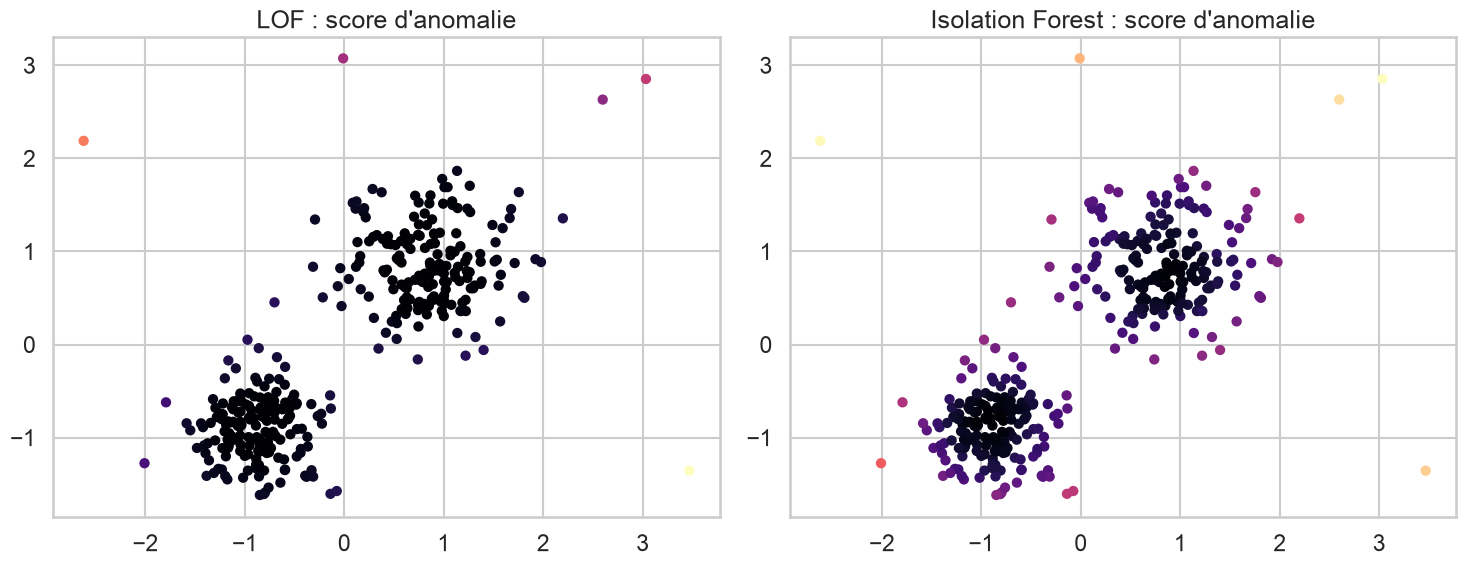

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(X6_std[:, 0], X6_std[:, 1], c=lof_scores, cmap='magma', s=35)
axes[0].set_title("LOF : score d'anomalie")

axes[1].scatter(X6_std[:, 0], X6_std[:, 1], c=iso_scores, cmap='magma', s=35)
axes[1].set_title("Isolation Forest : score d'anomalie")

plt.tight_layout()
plt.show()

### Étape 6.6 — Inspecter les observations individuellement
`out_df` regroupe, pour chaque observation, les scores et deux indicateurs booléens. L'expression `lof_labels == -1` renvoie `True` lorsque LOF a déclenché une alerte et `False` sinon. Le principe est identique pour Isolation Forest.

`sort_values(['score_lof', 'score_iso'], ascending=False)` trie d'abord par score LOF décroissant, puis utilise le score d'isolement pour départager d'éventuelles égalités. **Ce n'est pas un classement de consensus entre les deux méthodes.**

`head(10)` affiche dix lignes pour l'inspection ; cela ne signifie pas que dix anomalies ont été détectées. L'index reste celui du tableau d'origine, ce qui permet de retrouver les observations.

In [15]:
out_df = pd.DataFrame({
    'lof_anomalie': lof_labels == -1,
    'score_lof': lof_scores,
    'iso_anomalie': iso_labels == -1,
    'score_iso': iso_scores
})
out_df.sort_values(['score_lof', 'score_iso'], ascending=False).head(10)

,lof_anomalie,score_lof,iso_anomalie,score_iso
354,True,7.091211,True,0.746017
352,True,5.409822,True,0.782764
351,True,4.206156,True,0.785948
353,True,3.738561,True,0.724692
350,True,3.399817,True,0.759291
122,True,2.406971,True,0.648573
65,True,2.271720,False,0.581604
36,True,1.946111,False,0.561614
103,False,1.929880,False,0.556041
29,False,1.926600,False,0.551911


### Étape 6.7 — Mesurer l'accord entre les détecteurs
La table croisée suivante compte les combinaisons d'alertes sur **les 355 observations**, et pas seulement sur les dix lignes précédentes. `pd.crosstab` place les décisions LOF en lignes et celles d'Isolation Forest en colonnes.

Il s'agit d'un tableau d'accord entre deux modèles, **pas d'une matrice de confusion face à une vérité terrain**. Les deux modèles peuvent être d'accord et se tromper tous les deux au regard d'un objectif métier.

In [16]:
accord_anomalies = pd.crosstab(
    out_df['lof_anomalie'],
    out_df['iso_anomalie'],
    rownames=['Alerte LOF'],
    colnames=['Alerte Isolation Forest'],
)
accord_anomalies

Alerte Isolation Forest,False,True
Alerte LOF,,
False,345,2
True,2,6


<a id="reponse-q6"></a>
### Réponse Q6 — Les détecteurs signalent-ils les mêmes points ?
> Deux méthodes différentes signalent-elles les mêmes points atypiques ?

**Réponse directe : pas exactement.** LOF et Isolation Forest signalent chacun huit observations. Six sont communes aux deux méthodes, deux sont propres à LOF et deux à Isolation Forest, soit dix observations distinctes signalées au moins une fois.

| Situation | Nombre d'observations |
|---|---:|
| Aucune alerte | 345 |
| Alerte LOF uniquement | 2 |
| Alerte Isolation Forest uniquement | 2 |
| Alerte des deux méthodes | 6 |

Chaque méthode signale donc **8 observations**, soit environ 2,25 % du jeu. Le seuil demandé est de 2 %, mais `355 × 0,02 = 7,1` ne correspond pas à un nombre entier de points. Le seuil par quantile et la règle de comparaison donnent ici huit alertes ; des égalités de scores peuvent aussi modifier le nombre exact d'alertes.

Les cinq points ajoutés sont signalés par les deux méthodes. Chacune signale aussi trois points issus des nuages initiaux : un en commun et deux différents. Cela illustre la différence entre notre scénario d'injection et la définition statistique de l'atypique. Ce résultat sur des points artificiellement éloignés ne suffit pas à évaluer la détection de cas réels plus discrets.

**Pourquoi les listes diffèrent :** LOF regarde la densité relative au voisinage ; Isolation Forest regarde la facilité d'isolement par des coupures. Les cas 36 et 65 sont signalés seulement par LOF, les cas 86 et 206 seulement par Isolation Forest. Les cas 122 et 350 à 354 sont communs. Ces indices sont repris avec leurs coordonnées en Q7.4.

**Conclusion métier :** une alerte est une priorité d'investigation. Retenir l'intersection donnerait six cas à examiner, tandis que retenir l'union en donnerait dix. Ces choix modifient le volume de travail, mais aucun ne garantit à lui seul la qualité des alertes.

### Et pour de nouvelles observations ?
Ce notebook détecte les observations atypiques dans le jeu utilisé pour l'ajustement. Avec son réglage par défaut, LOF s'utilise ici via `fit_predict` et ne fournit pas un `predict` pour de nouveaux points. Pour un usage de détection de nouveautés, il faut ajuster un LOF avec `novelty=True` et réserver ensuite `predict` aux observations nouvelles. Isolation Forest peut appliquer `predict` à de nouvelles observations. Dans les deux cas, il faut réutiliser la transformation apprise sur les données de référence, sans la réajuster sur chaque nouveau lot.

Référence : [détection d'anomalies et de nouveautés](https://scikit-learn.org/stable/modules/outlier_detection.html).

## 7. Évaluer sans labels : une petite grille de lecture

### Question
Comment conclure proprement lorsqu'on n'a pas de vérité terrain complète ?

### Étape 7.1 — Comprendre la nature du tableau
La cellule suivante construit une liste de questions et de diagnostics possibles. Elle sert de plan de lecture. Les réponses Q7.1 à Q7.5 qui suivent appliquent cette grille aux données du notebook : stabilité mesurée, séparation observée, inspection du bruit, cas à examiner et sensibilité calculée.

1. **Stabilité :** changer la graine lorsque la méthode est aléatoire, rééchantillonner les données ou comparer des périodes. Vérifier que des structures similaires réapparaissent. Une permutation des numéros de groupes n'est pas, à elle seule, une instabilité.
2. **Séparation :** examiner la silhouette et les cas frontières dans l'espace utilisé pour l'ajustement. Une projection 2D peut masquer des écarts importants.
3. **Bruit :** inspecter les points exclus par DBSCAN. Ils peuvent être intéressants, mal mesurés ou simplement peu fréquents. HDBSCAN est mentionné comme prolongement pour explorer des structures de densité ; il n'est pas exécuté dans ce notebook.
4. **Utilité des anomalies :** examiner des cas avec un expert et relier le volume d'alertes à une capacité d'investigation.
5. **Sensibilité :** faire varier les paramètres et observer ce qui change. Une conclusion qui disparaît après une petite variation demande davantage d'examen.

In [17]:
summary = pd.DataFrame({
    'Question': [
        'Les groupes sont-ils stables ?',
        'Les groupes sont-ils séparés ?',
        'Existe-t-il du bruit interprétable ?',
        'Les anomalies sont-elles actionnables ?',
        'Le résultat dépend-il trop des paramètres ?'
    ],
    'Diagnostic possible': [
        'Changer la graine, sous-échantillonner, comparer plusieurs exécutions',
        'Silhouette, visualisation, distances intra/inter',
        'DBSCAN/HDBSCAN, inspection de cas limites',
        'Inspection métier, coût d’investigation, volume d’alertes',
        'Analyse de sensibilité sur eps, K, contamination, n_neighbors'
    ]
})
summary

,Question,Diagnostic possible
0,Les groupes sont-ils stables ?,"Changer la graine, sous-échantillonner, compar..."
1,Les groupes sont-ils séparés ?,"Silhouette, visualisation, distances intra/inter"
2,Existe-t-il du bruit interprétable ?,"DBSCAN/HDBSCAN, inspection de cas limites"
3,Les anomalies sont-elles actionnables ?,"Inspection métier, coût d’investigation, volum..."
4,Le résultat dépend-il trop des paramètres ?,"Analyse de sensibilité sur eps, K, contaminati..."


<a id="reponse-q7-1"></a>
### Réponse Q7.1 — Les groupes sont-ils stables ?
**Question de la grille :** Les groupes sont-ils stables ?

Nous testons ici la solution K-means à quatre groupes sur `X3`. Deux perturbations sont étudiées : changer la graine sur les 500 points, puis réajuster la standardisation et K-means sur des sous-échantillons de 400 points, tirés sans remise.

Pour comparer les partitions, tous les modèles affectent les **mêmes 500 observations, dans le même ordre**. Nous utilisons l'**indice de Rand ajusté (ARI)** : 1 signifie que les partitions sont identiques à une permutation des numéros de groupes près ; une valeur proche de 0 correspond à un accord comparable au hasard. Il peut aussi être négatif.

La référence est `labels4`, pas une vérité terrain. Le calcul mesure donc un accord entre partitions. Les affectations des 500 points après ajustement sur 400 servent à cette comparaison ; elles ne constituent pas un test indépendant de performance prédictive.

Référence : [adjusted_rand_score — documentation officielle](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html).

In [18]:
from sklearn.metrics import adjusted_rand_score

resultats_stabilite = []
for graine in [0, 7, 42]:
    labels_graine = KMeans(
        n_clusters=4, n_init=20, random_state=graine
    ).fit_predict(X3_std)
    resultats_stabilite.append({
        'experience': 'Graine seule',
        'graine': graine,
        'points_ajustement': len(X3),
        'ARI': adjusted_rand_score(labels4, labels_graine),
    })

    indices = np.random.RandomState(graine).choice(
        len(X3), size=int(0.8 * len(X3)), replace=False
    )
    scaler_echantillon = StandardScaler().fit(X3[indices])
    km_echantillon = KMeans(n_clusters=4, n_init=20, random_state=graine)
    km_echantillon.fit(scaler_echantillon.transform(X3[indices]))
    labels_echantillon = km_echantillon.predict(scaler_echantillon.transform(X3))
    resultats_stabilite.append({
        'experience': 'Sous-échantillon à 80 %',
        'graine': graine,
        'points_ajustement': len(indices),
        'ARI': adjusted_rand_score(labels4, labels_echantillon),
    })

stabilite = pd.DataFrame(resultats_stabilite)
stabilite

,experience,graine,points_ajustement,ARI
0,Graine seule,0,500,1.0
1,Sous-échantillon à 80 %,0,400,1.0
2,Graine seule,7,500,1.0
3,Sous-échantillon à 80 %,7,400,1.0
4,Graine seule,42,500,1.0
5,Sous-échantillon à 80 %,42,400,1.0


**Réponse Q7.1 : oui, dans les perturbations testées pour `X3`.** Les trois graines et les trois sous-échantillons donnent tous **ARI = 1,000** par rapport à la partition de référence. L'appartenance aux groupes est conservée, même si les identifiants ou les coordonnées des centroïdes peuvent changer.

**Portée de la réponse :** cela renforce le choix de K = 4 sur ce jeu bien séparé. Trois sous-échantillons ne prouvent pas une stabilité pour toutes les populations, toutes les périodes ou toutes les méthodes du notebook. Nous n'avons pas mesuré ici la stabilité du GMM ou de DBSCAN par rééchantillonnage.

<a id="reponse-q7-2"></a>
### Réponse Q7.2 — Les groupes sont-ils séparés ?
**Question de la grille :** Les groupes sont-ils séparés ?

**Réponse : oui pour la solution K = 4 sur `X3`, selon les diagnostics géométriques disponibles.** Sa silhouette moyenne est **0,844**, contre **0,759** pour K = 3 et **0,721** pour K = 5. La figure montre aussi quatre nuages compacts et espacés.

La réponse dépend toutefois du jeu et de la notion de séparation :
- Sur les lunes `X4`, les chaînes denses de DBSCAN suivent les arcs, alors que la séparation par centres de K-means coupe la structure de référence.
- Sur `X5`, DBSCAN avec `eps=0.30` relie 479 points dans un groupe : il n'identifie pas trois régions denses séparées avec ce réglage.

**Conclusion :** la séparation de `X3` est convaincante dans l'espace standardisé. On ne peut pas en déduire que toutes les partitions du notebook sont bonnes ni que leurs groupes correspondent à des catégories métier. Une silhouette élevée est un indice géométrique, pas une validation métier.

<a id="reponse-q7-3"></a>
### Réponse Q7.3 — Existe-t-il du bruit interprétable ?
**Question de la grille :** Existe-t-il du bruit interprétable ?

Inspectons les 17 points marqués `-1` par DBSCAN sur `X5`. Le tableau conserve leurs indices et leurs coordonnées dans les unités initiales. `ajout_manuel` indique les trois points ajoutés après la génération des 500 observations ; cette information sert uniquement à l'interprétation après ajustement.

In [19]:
cas_bruit = pd.DataFrame(X5, columns=['x1', 'x2'])
cas_bruit['ajout_manuel'] = np.arange(len(X5)) >= len(X5) - 3
cas_bruit = cas_bruit.loc[models['DBSCAN'] == -1]
cas_bruit

,x1,x2,ajout_manuel
54,-5.357771,-0.260288,False
108,1.375952,0.213639,False
166,1.886487,3.747052,False
178,2.341589,-2.259045,False
242,-5.917141,-1.921949,False
306,2.193284,3.646132,False
339,0.830170,0.340024,False
357,2.403643,3.964535,False
374,4.002545,3.955447,False
393,1.379224,0.373205,False


**Réponse Q7.3 : oui, géométriquement.** Les points ajoutés aux indices **500, 501 et 502**, de coordonnées `(6, 6)`, `(6.5, 5.8)` et `(-6, 4)`, sont tous marqués comme bruit. Ils sont éloignés des régions suffisamment denses pour le rayon retenu.

Les **14 autres points** de bruit viennent des nuages gaussiens initiaux. Leur exclusion signifie qu'ils ne sont rattachés à aucun groupe selon `eps=0.30` et `min_samples=6` ; elle ne prouve pas une erreur de mesure. Les points d'une distribution gaussienne peuvent aussi se situer dans ses zones peu denses.

**Conclusion :** le bruit est interprétable comme une faible connectivité locale dans cette représentation. Son interprétation métier demanderait le contexte des observations. La réponse Q7.5 montre aussi que son volume dépend fortement du rayon choisi.

<a id="reponse-q7-4"></a>
### Réponse Q7.4 — Les anomalies sont-elles actionnables ?
**Question de la grille :** Les anomalies sont-elles actionnables ?

Construisons la liste des observations signalées par au moins une méthode. Le `|` combine les deux conditions par un « ou ». Le tableau ajoute les coordonnées initiales et indique si le cas provient des cinq points injectés. Le tri par index facilite l'identification des cas ; ce n'est pas un classement de priorité.

In [20]:
cas_a_examiner = out_df.assign(
    x1=X6[:, 0],
    x2=X6[:, 1],
    ajout_manuel=np.arange(len(X6)) >= len(X6) - len(outliers),
)
cas_a_examiner = cas_a_examiner.loc[
    cas_a_examiner['lof_anomalie'] | cas_a_examiner['iso_anomalie']
].sort_index()
cas_a_examiner

,lof_anomalie,score_lof,iso_anomalie,score_iso,x1,x2,ajout_manuel
36,True,1.946111,False,0.561614,-1.587962,1.082185,False
65,True,2.271720,False,0.581604,-4.095796,-1.342478,False
86,False,1.771814,True,0.605078,5.078881,3.119575,False
122,True,2.406971,True,0.648573,-4.593014,-2.819510,False
206,False,1.743791,True,0.598036,-0.293573,-3.561670,False
350,True,3.399817,True,0.759291,6.000000,6.000000,True
351,True,4.206156,True,0.785948,7.000000,6.500000,True
352,True,5.409822,True,0.782764,-6.000000,5.000000,True
353,True,3.738561,True,0.724692,0.000000,7.000000,True
354,True,7.091211,True,0.746017,8.000000,-3.000000,True


**Réponse Q7.4 : elles sont inspectables, mais leur utilité opérationnelle n'est pas démontrée.** Nous avons dix cas identifiables, avec coordonnées, scores et décisions. Les six cas communs sont **122 et 350 à 354**. Les quatre désaccords concernent **36, 65, 86 et 206**.

Une procédure d'investigation possible serait :
1. Vérifier les données et le contexte des cinq points ajoutés, puis du point 122 signalé par les deux méthodes.
2. Examiner les quatre désaccords pour comprendre ce que privilégie chaque détecteur.
3. Décider avec un expert de l'action pertinente, consigner le résultat de l'examen et adapter le seuil au coût et au volume d'alertes.

Dans cet exercice, `x1` et `x2` n'ont pas de signification opérationnelle et aucun coût ni résultat d'investigation n'est fourni. Il serait donc injustifié d'affirmer que ces cas sont des fraudes ou qu'une intervention serait rentable. **Un score permet de sélectionner des cas à examiner ; le contexte et le retour d'investigation permettent de justifier une action.**

<a id="reponse-q7-5"></a>
### Réponse Q7.5 — Le résultat dépend-il trop des paramètres ?
**Question de la grille :** Le résultat dépend-il trop des paramètres ?

Nous avons déjà mesuré l'effet de **K** en section 3 : K = 4 donne la meilleure silhouette parmi les valeurs 2 à 7. Complétons la réponse avec les trois autres paramètres cités dans la grille, en ne changeant qu'un paramètre à la fois.

**A. Effet de `eps` sur DBSCAN.** Nous conservons `X5_std` et `min_samples=6`, puis testons les trois rayons proposés en section 5. Les effectifs sont comptés après exclusion du bruit.

In [21]:
resultats_eps = []
for eps_test in [0.20, 0.30, 0.40]:
    labels_eps = DBSCAN(eps=eps_test, min_samples=6).fit_predict(X5_std)
    groupes_eps, effectifs_eps = np.unique(
        labels_eps[labels_eps != -1], return_counts=True
    )
    resultats_eps.append({
        'eps': eps_test,
        'nombre_groupes': len(groupes_eps),
        'effectifs_groupes': effectifs_eps.tolist(),
        'points_bruit': int(np.sum(labels_eps == -1)),
    })

sensibilite_eps = pd.DataFrame(resultats_eps)
sensibilite_eps

,eps,nombre_groupes,effectifs_groupes,points_bruit
0,0.2,5,"[152, 111, 153, 6, 8]",73
1,0.3,2,"[479, 7]",17
2,0.4,1,[497],6


**Résultat de l'expérience sur `eps` :**

| `eps` | Nombre de groupes | Effectifs des groupes | Points de bruit |
|---:|---:|---|---:|
| 0,20 | 5 | 152, 111, 153, 6, 8 | 73 |
| 0,30 | 2 | 479, 7 | 17 |
| 0,40 | 1 | 497 | 6 |

Le petit rayon fragmente la structure et exclut davantage de points. En augmentant le rayon, les voisinages se relient, les groupes fusionnent et le bruit diminue. **La segmentation DBSCAN de `X5` est donc fortement sensible à la plage de rayons testée.** Retenir uniquement le graphique obtenu avec 0,30 masquerait ce constat.

**B. Effet de `contamination` sur les alertes.** Nous fixons le voisinage de LOF à 20 et la graine d'Isolation Forest à 42, puis comparons les seuils correspondant à 1 %, 2 % et 5 %.

In [22]:
resultats_contamination = []
for contamination_test in [0.01, 0.02, 0.05]:
    alertes_lof = LocalOutlierFactor(
        n_neighbors=20, contamination=contamination_test
    ).fit_predict(X6_std) == -1
    alertes_iso = IsolationForest(
        contamination=contamination_test, random_state=42
    ).fit_predict(X6_std) == -1
    resultats_contamination.append({
        'contamination': contamination_test,
        'alertes_LOF': int(alertes_lof.sum()),
        'alertes_Isolation_Forest': int(alertes_iso.sum()),
        'alertes_communes': int((alertes_lof & alertes_iso).sum()),
    })

sensibilite_contamination = pd.DataFrame(resultats_contamination)
sensibilite_contamination

,contamination,alertes_LOF,alertes_Isolation_Forest,alertes_communes
0,0.01,4,4,3
1,0.02,8,8,6
2,0.05,18,18,14


**Résultat :** à 1 %, 2 % et 5 %, chaque détecteur signale respectivement **4, 8 et 18 points**. Les nombres d'alertes communes sont **3, 6 et 14**. Le volume de travail change nettement.

À données, voisinage et graine fixés, ce paramètre agit ici sur le **seuil**, pas sur le classement par score. Ajouter des alertes en augmentant `contamination` ne prouve donc pas une amélioration du détecteur ni une augmentation du nombre réel d'anomalies.

**C. Effet de `n_neighbors` sur LOF.** Nous fixons maintenant `contamination=0.02` et comparons des voisinages de 10, 20 et 40 points. La référence est la liste d'alertes du LOF initial à 20 voisins. Nous comptons les alertes communes et les observations dont la décision a changé.

In [23]:
resultats_voisinage = []
reference_lof = lof_labels == -1
for voisins_test in [10, 20, 40]:
    alertes_voisins = LocalOutlierFactor(
        n_neighbors=voisins_test, contamination=0.02
    ).fit_predict(X6_std) == -1
    resultats_voisinage.append({
        'n_neighbors': voisins_test,
        'alertes_LOF': int(alertes_voisins.sum()),
        'communes_reference': int((alertes_voisins & reference_lof).sum()),
        'decisions_modifiees': int((alertes_voisins != reference_lof).sum()),
    })

sensibilite_voisinage = pd.DataFrame(resultats_voisinage)
sensibilite_voisinage

,n_neighbors,alertes_LOF,communes_reference,decisions_modifiees
0,10,8,7,2
1,20,8,8,0
2,40,8,8,0


**Résultat sur le voisinage :** les trois réglages donnent huit alertes, mais leurs listes ne sont pas toutes identiques. Avec 10 voisins, sept alertes sont communes à la référence : une observation entre dans la liste et une autre en sort, soit **deux décisions modifiées**. Avec 20 et 40 voisins, les listes d'alertes sont identiques dans ce test.

**Réponse Q7.5 : la sensibilité est mesurée, et elle diffère selon le paramètre.**
- **K :** K = 4 est soutenu par la meilleure silhouette de la grille et par la stabilité mesurée en Q7.1.
- **`eps` :** la partition de `X5` passe de cinq groupes à un seul dans la plage testée ; sa structure demande donc une justification soigneuse du rayon.
- **`contamination` :** le seuil pilote volontairement le volume d'alertes, qui doit être relié à une capacité d'investigation.
- **`n_neighbors` :** le nombre d'alertes reste constant, mais certaines identités changent ; regarder seulement le nombre d'alertes serait insuffisant.

Le mot **« trop »** suppose une tolérance métier : quel changement de segmentation ou d'alerte rend la décision inutilisable ? Sans cette exigence, on peut constater et quantifier la sensibilité, mais pas fixer un seuil universel d'acceptabilité. Nous n'avons exploré que les valeurs affichées ; ces résultats ne prouvent pas une robustesse à tous les réglages, notamment à d'autres valeurs de `min_samples`.

<a id="reponse-q7"></a>
### Réponse Q7 — Conclure sans vérité terrain complète
> Comment conclure proprement lorsqu'on n'a pas de vérité terrain complète ?

**Réponse directe :** on formule une conclusion limitée au périmètre observé en croisant la représentation, la séparation, la stabilité, la sensibilité aux paramètres et l'inspection des cas. Chaque affirmation doit être rattachée à un résultat, puis accompagnée de ce que ce résultat ne permet pas d'établir.

**Application à ce notebook :**
1. **Segmentation de `X3` :** K = 4 est une solution exploratoire bien soutenue : silhouette de 0,844 et ARI de 1 sur les changements de graine et sous-échantillons testés.
2. **Géométrie et paramètres :** DBSCAN suit les lunes, mais sa partition sur `X5` est sensible à `eps`. Il n'y a donc pas de méthode gagnante pour tous les jeux.
3. **Anomalies de `X6` :** dix cas distincts sont signalés au moins une fois, dont six par les deux méthodes. Ce sont des candidats à l'inspection, pas des incidents confirmés.
4. **Décision métier :** les variables étant synthétiques et sans contexte opérationnel, l'utilité réelle des groupes et des alertes reste à établir.

### Limites à rappeler dans la conclusion
- **Une graine fixe rend l'expérience reproductible, pas nécessairement robuste.** La robustesse demande d'autres expériences.
- **Un score interne n'est pas une mesure de justesse métier.** La silhouette évalue une géométrie, pas l'intérêt des segments.
- **Le bruit n'est pas un groupe ordinaire.** Pour calculer une silhouette après DBSCAN, il faut expliciter le traitement des points `-1`. Si on les exclut, on doit aussi rapporter leur proportion.
- **La silhouette n'est pas toujours définie.** Sur les points évalués, il faut au moins deux étiquettes distinctes et moins d'étiquettes que de points. Un seul groupe après exclusion du bruit ne permet pas ce calcul.
- **Un petit groupe n'est pas automatiquement une anomalie.** Il peut représenter un comportement rare mais légitime.
- **Un score d'anomalie élevé n'est pas une preuve d'incident.** Il faut examiner les caractéristiques du cas et son contexte.

### Exemple de formulation professionnelle
« Sur ce jeu synthétique, K = 4 est soutenu par le coude, une silhouette de 0,844 et des partitions identiques sur les trois graines et les trois sous-échantillons testés. Ce résultat justifie une segmentation exploratoire. Avant un usage métier, nous devons vérifier son comportement sur des données représentatives du contexte visé et décrire les profils des groupes. »

Cette formulation distingue ce qui a été **observé**, l'**interprétation** proposée et ce qui **reste à vérifier**. Les ajustements et les scores de ce notebook décrivent les données présentes ; ils ne constituent pas un test de généralisation sur des observations futures.

**Conclusion attendue :** un résultat non supervisé est un diagnostic argumenté, fondé sur plusieurs indices complémentaires.

## 8. Mini synthèse à retenir

### Les cinq messages de la journée
1. Un cluster dépend de la représentation des données et de la notion de proximité.
2. La PCA privilégie la variance ; une projection peut perdre de l'information utile.
3. K-means, GMM et DBSCAN expriment des hypothèses géométriques différentes.
4. LOF et Isolation Forest donnent deux définitions complémentaires de l'atypique.
5. Sans labels, on conclut par convergence d'indices et inspection des cas.

### Question de restitution
Rédiger en 8 à 10 lignes :
- la méthode que vous choisiriez pour des groupes compacts ;
- la méthode que vous choisiriez pour des formes courbes ;
- la méthode d'anomalie que vous testeriez en premier ;
- ce que vous vérifieriez avant toute conclusion métier.

Essayez de répondre sans relire les sections précédentes, puis comparez votre raisonnement à la proposition suivante. Plusieurs réponses sont possibles si les hypothèses et les vérifications sont justifiées.

### Restitution : réponse à chacun des quatre points demandés

<a id="reponse-q8-1"></a>
#### Q8.1 — La méthode que vous choisiriez pour des groupes compacts
**Je choisirais K-means comme première méthode**, après examen de l'échelle des variables. Son critère de distance à des centroïdes convient à des nuages compacts et assez bien séparés. Je comparerais plusieurs K : ici, K = 4 est soutenu par la silhouette de 0,844 et les tests de stabilité. Si les groupes sont elliptiques ou présentent des recouvrements importants, je comparerais aussi un GMM.

<a id="reponse-q8-2"></a>
#### Q8.2 — La méthode que vous choisiriez pour des formes courbes
**Je testerais DBSCAN** si les courbes correspondent à des régions denses séparées par des zones moins denses. Il suit des connexions locales sans imposer de centroïdes. Sur les lunes, il produit deux groupes et un point de bruit. Je vérifierais `eps` et `min_samples` : l'exemple `X5` montre que changer de rayon peut fusionner les groupes. Une forme courbe à elle seule ne garantit donc pas le succès de DBSCAN.

<a id="reponse-q8-3"></a>
#### Q8.3 — La méthode d'anomalie que vous testeriez en premier
**Je commencerais par Isolation Forest pour ce cas**, car les points ajoutés sont isolés du reste du nuage et la méthode traduit directement cette hypothèse par des coupures. Je le comparerais à LOF pour détecter des écarts au voisinage local. Ici, les deux méthodes retrouvent les cinq points ajoutés : ce constat ne donne pas de supériorité générale à l'une d'elles. Je commencerais plutôt par LOF si la question métier concernait explicitement un écart par rapport à des observations voisines comparables.

<a id="reponse-q8-4"></a>
#### Q8.4 — Ce que vous vérifieriez avant toute conclusion métier
**Je vérifierais cinq points :** la pertinence et la qualité des variables ; la représentation et les distances ; la séparation et la stabilité des groupes ; la sensibilité aux paramètres et aux seuils ; enfin, les profils de groupes ou les cas d'alerte avec un expert du contexte. Si une PCA sert à visualiser, je préciserais la variance conservée. Pour les anomalies, je relierais le volume d'alertes à une action possible, à son coût et au retour d'investigation. Dans ce notebook, le sens métier et les coûts ne sont pas fournis : la conclusion reste exploratoire.

<a id="synthese-redigee"></a>
### Proposition de correction en dix lignes
1. Je commence par examiner les variables, leurs unités et la pertinence d'une standardisation.
2. Pour des groupes compacts, je teste K-means et compare plusieurs valeurs de K.
3. Ici, K = 4 est soutenu par le coude, une silhouette de 0,844 et la stabilité sur les perturbations testées.
4. Si les groupes semblent elliptiques ou se recouvrent, je compare aussi un mélange gaussien.
5. Pour des formes courbes reliées par des zones denses, je teste DBSCAN en étudiant `eps` et `min_samples`.
6. Pour une première exploration des anomalies tabulaires, je teste Isolation Forest et inspecte les points les mieux classés.
7. Je compare ensuite avec LOF lorsque l'écart au voisinage local paraît important.
8. Je distingue les scores des alertes et relie le seuil au volume de cas que l'équipe peut examiner.
9. Si j'utilise une PCA pour visualiser, je rapporte la variance conservée et ce que la projection peut masquer.
10. Je conclus à partir de résultats stables et de cas inspectés, sans présenter les groupes ou alertes comme une vérité absolue.

Commencer par LOF serait également défendable si la question porte explicitement sur un comportement inhabituel par rapport à des voisins comparables. Le choix doit être motivé, pas récité.

### Petit glossaire pour réviser
| Terme | Définition à retenir |
|---|---|
| Représentation | Variables et transformations choisies pour décrire les observations. |
| Cluster | Groupe construit selon le critère d'une méthode. |
| Centroïde | Moyenne des coordonnées des points d'un groupe. |
| Composante principale | Nouvel axe linéaire construit pour expliquer de la variance. |
| Inertie | Somme des distances au carré aux centroïdes affectés. |
| Silhouette | Indicateur de compacité et de séparation selon une distance. |
| Covariance | Description de la variation conjointe des variables ; elle détermine notamment l'orientation d'une gaussienne. |
| Densité locale | Concentration d'observations autour d'un point à une échelle donnée. |
| Bruit DBSCAN | Observation non rattachée à un groupe pour les paramètres choisis. |
| Score d'anomalie | Valeur permettant de classer les observations selon leur caractère atypique. |
| Seuil | Règle transformant un score en décision d'alerte. |
| Stabilité | Persistance d'une structure lorsque les conditions de l'expérience varient. |

### Pour approfondir
Les références officielles sont indiquées dans chaque section. Pour relier les méthodes et leurs limites, lire aussi le [guide scikit-learn du clustering](https://scikit-learn.org/stable/modules/clustering.html) et celui de la [détection d'anomalies](https://scikit-learn.org/stable/modules/outlier_detection.html).

**Dernière vérification personnelle :** pouvez-vous expliquer pourquoi K-means réussit en section 3 mais coupe les lunes en section 4, puis pourquoi DBSCAN réussit sur les lunes mais fusionne presque tous les points en section 5 ?

**Réponse :** les quatre nuages de `X3` sont compacts et séparés, ce qui correspond au critère de K-means. Les lunes de `X4` sont des arcs imbriqués : les représenter par deux centres conduit à les couper, tandis que DBSCAN suit leur continuité dense. Sur `X5`, des chaînes de voisinages relient au contraire les nuages avec `eps=0.30`, si bien que DBSCAN rassemble 479 observations dans un même groupe. La réussite dépend donc de l'accord entre la géométrie, la représentation et les paramètres de la méthode.

Si une étape reste floue, formulez une question précise à partir du code, du graphique ou d'une observation particulière pour en discuter avec le formateur.